In [22]:
# ===============================
# Step 1: Load CSV into DataFrame
# ===============================

from google.colab import files
uploaded = files.upload()


Saving hotel_bookings.csv to hotel_bookings (3).csv


In [23]:
import pandas as pd

df = pd.read_csv("hotel_bookings.csv")

# Optional preview
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [24]:
# ======================================
# Step 2: Initial Data Audit and Preview
# ======================================

# Check dataset structure
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False))

# View unique values for key categorical columns
categorical_cols = ['hotel', 'market_segment', 'customer_type', 'deposit_type', 'distribution_channel']
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())




Shape: (119390, 32)

Data types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
a

In [25]:
#high missingness but are not needed for your current experimental design:
#company (94% missing): optional ID field, safe to ignore
#agent (13% missing): can be excluded unless you're analyzing booking intermediaries
#country: low missingness (488 rows), could be dropped or imputed if needed
#children: only 4 missing values — could drop or fill with 0

In [26]:
# Drop rows with missing 'children'
df = df[df['children'].notna()]

# Optionally drop irrelevant columns
df = df.drop(columns=['company', 'agent'])


In [27]:
df['market_segment'].value_counts()

,count
market_segment,
Online TA,56476
Offline TA/TO,24219
Groups,19811
Direct,12605
Corporate,5295
Complementary,743
Aviation,237


In [28]:
# =====================================
# Step 3: Define Treatment (Booking Channel)
# =====================================

# Drop undefined market_segment rows (if any)
df = df[df['market_segment'] != 'Undefined']


df['market_segment'].value_counts()

# Create new binary treatment group based on booking channel
df['booking_channel'] = df['market_segment'].apply(
    lambda x: 'Online' if x == 'Online TA' else 'Offline'
)

# Check result
df['booking_channel'].value_counts()



,count
booking_channel,
Offline,62910
Online,56476


In [29]:
df[['market_segment', 'booking_channel']].head(10)

,market_segment,booking_channel
0,Direct,Offline
1,Direct,Offline
2,Direct,Offline
3,Corporate,Offline
4,Online TA,Online
5,Online TA,Online
6,Direct,Offline
7,Direct,Offline
8,Online TA,Online
9,Offline TA/TO,Offline


In [30]:
# ==========================================================
# Step 4: Compare Cancellation Rates by Booking Channel
# ==========================================================


#Cancellation rate = mean of is_canceled (1 = canceled) grouped by booking channel

cancellation_rates = df.groupby('booking_channel')['is_canceled'].agg(['mean', 'count'])
cancellation_rates.rename(columns={'mean': 'cancellation_rate', 'count': 'n'}, inplace=True)
display(cancellation_rates)

#This gives:
#Mean = cancellation rate (proportion of bookings canceled)
#Count = number of bookings in each group

,cancellation_rate,n
booking_channel,,
Offline,0.373263,62910
Online,0.367200,56476


<ipython-input-31-6c38f8016706>:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='booking_channel', y='is_canceled', data=df, estimator='mean', ci=95)


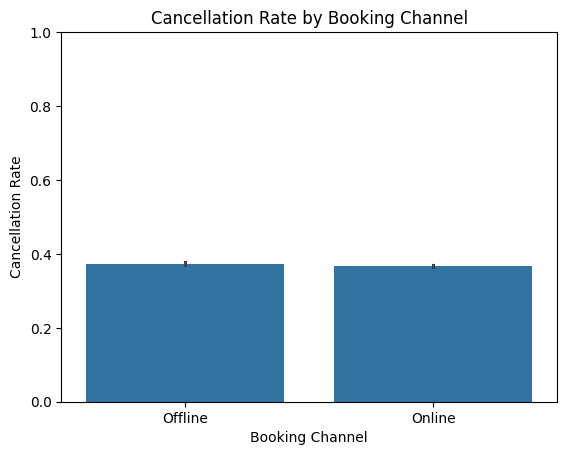

In [31]:
# =============================================
# Step 4B: Visualize Cancellation Rate (Barplot)
# =============================================

import seaborn as sns
import matplotlib.pyplot as plt

# Barplot showing mean cancellation rate with 95% CI
sns.barplot(x='booking_channel', y='is_canceled', data=df, estimator='mean', ci=95)
plt.title('Cancellation Rate by Booking Channel')
plt.ylabel('Cancellation Rate')
plt.xlabel('Booking Channel')
plt.ylim(0, 1)
plt.show()


In [45]:
# =====================================================
# Step 4C: Updated Cancellation Rates by Booking Channel
# =====================================================

# Group by booking_channel and calculate cancellation rate and count
cancellation_rates = df.groupby('booking_channel')['is_canceled'].agg(['mean', 'count'])
cancellation_rates.rename(columns={'mean': 'cancellation_rate', 'count': 'n'}, inplace=True)
display(cancellation_rates)

# -------------------------------------------------------
# This gives the current cancellation rate per group
# after cleaning and reclassifying booking_channel.
# We'll use these counts in the z-test next.
# -------------------------------------------------------


,cancellation_rate,n
booking_channel,,
Offline,0.373263,62910
Online,0.367200,56476


In [46]:
# =====================================================
# Step 4D: Two-Proportion Z-Test for Cancellation Rates
# =====================================================

from statsmodels.stats.proportion import proportions_ztest

# Count cancellations in each group
cancel_counts = [
    df[(df['booking_channel'] == 'Online') & (df['is_canceled'] == 1)].shape[0],
    df[(df['booking_channel'] == 'Offline') & (df['is_canceled'] == 1)].shape[0]
]

# Total observations per group
n_obs = [
    df[df['booking_channel'] == 'Online'].shape[0],
    df[df['booking_channel'] == 'Offline'].shape[0]
]

# Perform two-proportion z-test
z_stat, p_val = proportions_ztest(cancel_counts, n_obs)

# Print result
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# -------------------------------------------------------
# Interpretation:
# This tests the null hypothesis that the cancellation
# rates are the same in Online and Offline groups.
# It does NOT control for lead time, deposit type, etc.
# -------------------------------------------------------


Z-statistic: -2.1659
P-value: 0.0303


In [ ]:
#A two-proportion z-test was conducted to compare cancellation rates between Online and Offline booking channels. The null hypothesis assumes equal cancellation rates.

#The test yielded a Z-statistic of –2.17 and a p-value of 0.0303, indicating a statistically significant difference in cancellation rates at the 5% level (α = 0.05).
#Specifically, the Offline group had a slightly higher cancellation rate (37.33%) compared to the Online group (36.72%).

#However, this unadjusted test does not account for confounding variables such as lead time, deposit type, or customer profile.
#We therefore proceed to a covariate-adjusted logistic regression model to better isolate the true effect of booking channel on cancellation behavior.


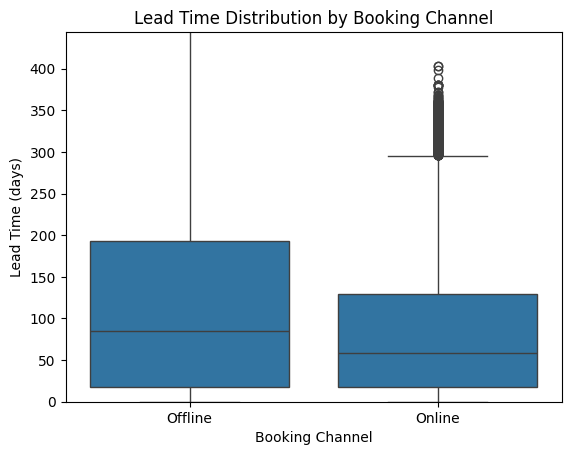

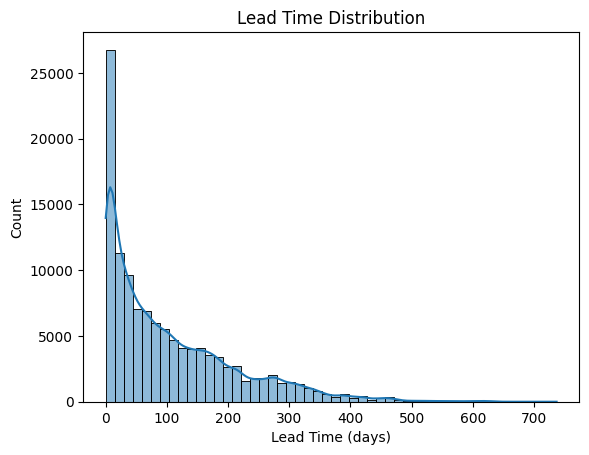

In [40]:
# ============================================
# Step 5: Covariate Balance — Lead Time Check
# ============================================

import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot: Compare lead_time between Online and Offline groups
sns.boxplot(x='booking_channel', y='lead_time', data=df)

# Add title and axis labels
plt.title('Lead Time Distribution by Booking Channel')
plt.ylabel('Lead Time (days)')
plt.xlabel('Booking Channel')

# Limit y-axis to reduce visual skew from extreme outliers
plt.ylim(0, df['lead_time'].quantile(0.99))

# Display the plot
plt.show()

# -------------------------------------------------------
# Interpretation:
# Offline bookings have longer lead times on average,
# and their distribution is much more spread out.
# This imbalance suggests lead_time could confound
# the relationship between booking_channel and is_canceled.
# We'll include it as a covariate in our regression model.
# -------------------------------------------------------



# Visualize lead_time distribution
import seaborn as sns
sns.histplot(df['lead_time'], kde=True, bins=50)
plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (days)')
plt.show()

# -------------------------------------------------------
# Interpretation:
# The distribution of lead_time is highly right-skewed.
# Most bookings occur within the first 100 days before check-in,
# with a long tail extending beyond 400 days.
#
# Despite this skew, logistic regression does not require
# predictors to be normally distributed — so we can proceed
# with raw lead_time as a covariate.
#
# Optional: If needed later, we can apply a log-transform using np.log1p().
# -------------------------------------------------------







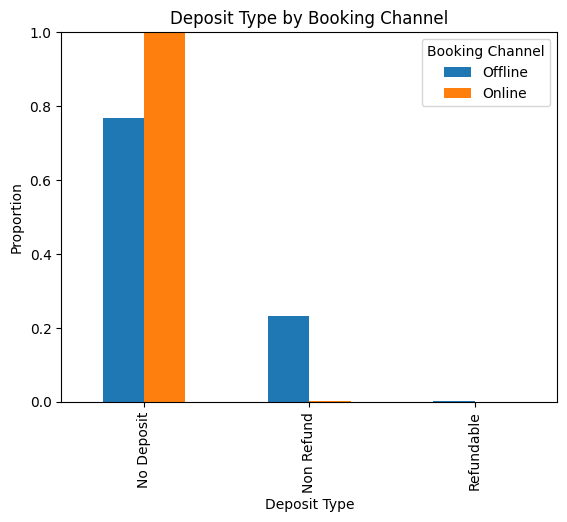

In [41]:
# ==========================================================
# Step 5B: Covariate Balance — Deposit Type (Side-by-Side)
# ==========================================================

# Cross-tab: proportion of deposit types by booking_channel
deposit_crosstab = pd.crosstab(df['deposit_type'], df['booking_channel'], normalize='columns')

# Plot deposit type distribution by channel (side-by-side bars)
deposit_crosstab.plot(kind='bar')
plt.title('Deposit Type by Booking Channel')
plt.ylabel('Proportion')
plt.xlabel('Deposit Type')
plt.legend(title='Booking Channel')
plt.ylim(0, 1)
plt.show()

# -------------------------------------------------------
# Interpretation:
# 'Non Refund' deposits are far more common in Offline bookings (~23% vs <0.1%).
# This is a strong confounder: customers who can't cancel won't cancel,
# regardless of booking method. We'll control for this.
# -------------------------------------------------------



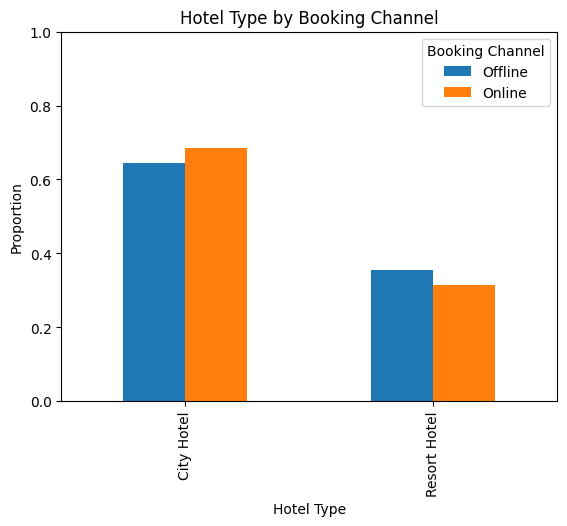

In [42]:
# ========================================================
# Step 5C: Covariate Balance — Hotel Type (Side-by-Side)
# ========================================================

# Cross-tab: proportion of hotel types by booking_channel
hotel_crosstab = pd.crosstab(df['hotel'], df['booking_channel'], normalize='columns')

# Plot hotel type distribution by channel (side-by-side bars)
hotel_crosstab.plot(kind='bar')
plt.title('Hotel Type by Booking Channel')
plt.ylabel('Proportion')
plt.xlabel('Hotel Type')
plt.legend(title='Booking Channel')
plt.ylim(0, 1)
plt.show()

# -------------------------------------------------------
# Interpretation:
# City vs Resort hotel balance is similar across channels (~68% City for Online vs ~64.5% Offline).
# This small imbalance may still be worth controlling for,
# in case hotel type moderates cancellation behavior.
# -------------------------------------------------------



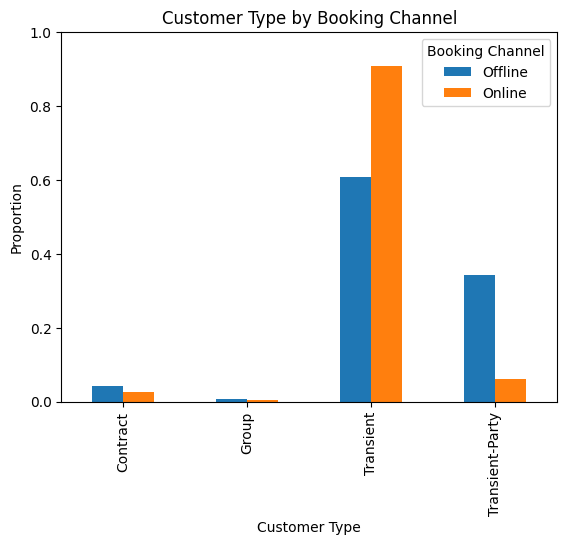

In [43]:
# ===========================================================
# Step 5D: Covariate Balance — Customer Type Distribution
# ===========================================================

# Compare distribution of customer_type across booking channels
customer_crosstab = pd.crosstab(df['customer_type'], df['booking_channel'], normalize='columns')

# Side-by-side bar plot
customer_crosstab.plot(kind='bar')
plt.title('Customer Type by Booking Channel')
plt.ylabel('Proportion')
plt.xlabel('Customer Type')
plt.legend(title='Booking Channel')
plt.ylim(0, 1)
plt.show()

# -------------------------------------------------------
# This covariate reflects guest intent (e.g., Group vs Transient).
# If one booking channel has more 'Group' or 'Contract' bookings,
# that could affect cancellation behavior. We’ll evaluate imbalance.
# -------------------------------------------------------

# -------------------------------------------------------
# Interpretation:
# Online bookings are overwhelmingly 'Transient' (~89%),
# while Offline bookings have a more diverse mix:
# ~61% Transient and ~35% Transient-Party.
# This imbalance could reflect different guest profiles
# (e.g., solo vs family/group travelers) and potentially
# impact cancellation behavior. We will control for it.
# ------------------------------------------------------


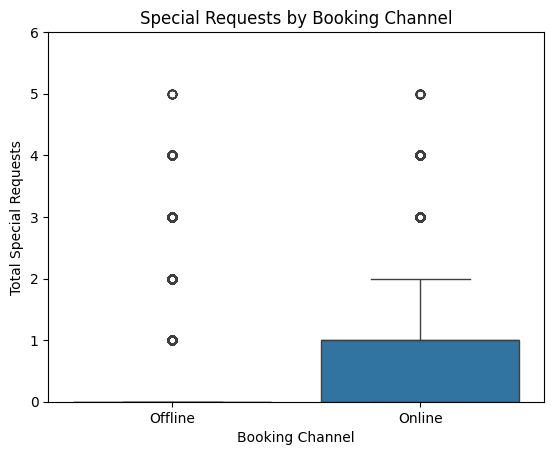

In [44]:
# ================================================================
# Step 5E: Covariate Balance — Total Special Requests Distribution
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt

# Create boxplot of total special requests across booking channels
sns.boxplot(x='booking_channel', y='total_of_special_requests', data=df)
plt.title('Special Requests by Booking Channel')
plt.xlabel('Booking Channel')
plt.ylabel('Total Special Requests')
plt.ylim(0, df['total_of_special_requests'].max() + 1)
plt.show()

# -------------------------------------------------------
# Guests with more special requests are likely more committed.
# This behavioral covariate may reduce cancellation probability.
# We’ll assess if it differs by booking channel and control for it.
# -------------------------------------------------------

# -------------------------------------------------------
# Interpretation:
# Online bookings show slightly higher total special requests
# than Offline bookings (median = 1 vs 0).
# Special requests may reflect customer engagement or commitment,
# and are expected to reduce cancellation probability.
# We will include this as a numeric covariate in our model.
# -------------------------------------------------------




In [49]:
# =========================================================
# Step 6: Logistic Regression with Covariate Adjustment
# =========================================================

import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# -------------------------------------------------------
# Convert relevant variables to categorical for modeling
# -------------------------------------------------------
df['booking_channel'] = df['booking_channel'].astype('category')        # Treatment
df['deposit_type'] = df['deposit_type'].astype('category')              # Refund policy
df['hotel'] = df['hotel'].astype('category')                            # City vs Resort
df['customer_type'] = df['customer_type'].astype('category')            # Guest intent

# -------------------------------------------------------
# Fit logistic regression model
# Outcome: is_canceled (binary)
# Predictors: booking_channel (treatment),
# plus covariates: lead_time, deposit_type, hotel,
# customer_type, total_of_special_requests
# -------------------------------------------------------

model = smf.logit(
    "is_canceled ~ booking_channel + lead_time + deposit_type + hotel + customer_type + total_of_special_requests",
    data=df
).fit()

# View model summary
model.summary()

# -------------------------------------------------------
# Interpretation:
# Coefficients are in log-odds scale.
# We'll convert them to odds ratios next.
# -------------------------------------------------------


Optimization terminated successfully.
         Current function value: 0.473881
         Iterations 9


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            is_canceled   No. Observations:               119386
Model:                          Logit   Df Residuals:                   119376
Method:                           MLE   Df Model:                            9
Date:                Fri, 09 May 2025   Pseudo R-squ.:                  0.2811
Time:                        00:57:57   Log-Likelihood:                -56575.
converged:                       True   LL-Null:                       -78695.
Covariance Type:            nonrobust   LLR p-value:                     0.000
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           -1.8864      0.046    -41.041      0.000      -1.977      -1.796
booking_channel[T.Online]            1.2666      0.018     68.761      0.000       1.231       1.303
deposit_type[T.Non Refund]           5.7886      0.105     54.958      0.000       5.582       5.995
deposit_type[T.Refundable]          -0.0846      0.198     -0.427      0.669      -0.473       0.304
hotel[T.Resort Hotel]               -0.1878      0.016    -12.017      0.000      -0.218      -0.157
customer_type[T.Group]              -0.6456      0.150     -4.318      0.000      -0.939      -0.353
customer_type[T.Transient]           0.3464      0.045      7.771      0.000       0.259       0.434
customer_type[T.Transient-Party]    -0.0320      0.047     -0.685      0.493      -0.124       0.060
lead_time                            0.0049   7.97e-05     61.436      0.000       0.005       0.005
total_of_special_requests           -0.7295      0.011    -66.340      0.000      -0.751      -0.708
====================================================================================================
"""

In [50]:
# ========================================================
# Convert coefficients to odds ratios for interpretability
# ========================================================

# Odds ratios from model coefficients
odds_ratios = np.exp(model.params)

# Confidence intervals for odds ratios
conf_int = model.conf_int()
conf_int_exp = np.exp(conf_int)
conf_int_exp.columns = ['CI Lower (2.5%)', 'CI Upper (97.5%)']

# Combine results into a summary table
odds_table = pd.concat([odds_ratios, conf_int_exp], axis=1)
odds_table.columns = ['Odds Ratio', 'CI Lower (2.5%)', 'CI Upper (97.5%)']

# Display the table
display(odds_table)

# -------------------------------------------------------
# Interpretation notes:
# Odds Ratio > 1 → Increases cancellation odds
# Odds Ratio < 1 → Decreases cancellation odds
# If CI crosses 1 → Not statistically significant
# -------------------------------------------------------


,Odds Ratio,CI Lower (2.5%),CI Upper (97.5%)
Intercept,0.151609,0.138548,0.165902
booking_channel[T.Online],3.548922,3.423076,3.679395
deposit_type[T.Non Refund],326.561654,265.649679,401.440402
deposit_type[T.Refundable],0.918876,0.623158,1.354926
hotel[T.Resort Hotel],0.828792,0.803793,0.854569
customer_type[T.Group],0.524342,0.391151,0.702885
customer_type[T.Transient],1.413958,1.295664,1.543053
customer_type[T.Transient-Party],0.968508,0.883810,1.061323
lead_time,1.004910,1.004753,1.005067
total_of_special_requests,0.482156,0.471876,0.492660


In [51]:
# =============================================================
# Step 6B: Progressive Models to Compare Booking Channel Effect
# =============================================================

import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# ---------------------------------------------
# Fit Model 1: Booking Channel only (unadjusted)
# ---------------------------------------------
model1 = smf.logit("is_canceled ~ booking_channel", data=df).fit(disp=0)

# ---------------------------------------------
# Fit Model 2: + lead_time
# ---------------------------------------------
model2 = smf.logit("is_canceled ~ booking_channel + lead_time", data=df).fit(disp=0)

# ---------------------------------------------
# Fit Model 3: + deposit_type
# ---------------------------------------------
model3 = smf.logit("is_canceled ~ booking_channel + lead_time + deposit_type", data=df).fit(disp=0)

# ---------------------------------------------------
# Extract odds ratio and CI for booking_channel[T.Online]
# ---------------------------------------------------
def extract_booking_channel_effect(model):
    or_val = np.exp(model.params['booking_channel[T.Online]'])
    ci_low, ci_high = np.exp(model.conf_int().loc['booking_channel[T.Online]'])
    return pd.Series({'Odds Ratio': or_val, 'CI Lower': ci_low, 'CI Upper': ci_high})

results_table = pd.DataFrame({
    'Model 1\n(Booking Channel Only)': extract_booking_channel_effect(model1),
    'Model 2\n+ lead_time': extract_booking_channel_effect(model2),
    'Model 3\n+ deposit_type': extract_booking_channel_effect(model3),
}).T

# Display comparison
display(results_table)

# ---------------------------------------------------
# Interpretation:
# Track how the odds ratio for booking_channel shifts
# across models. If it remains stable, the effect is robust.
# ---------------------------------------------------


,Odds Ratio,CI Lower,CI Upper
Model 1\n(Booking Channel Only),0.974330,0.951670,0.997530
Model 2\n+ lead_time,1.260280,1.228991,1.292366
Model 3\n+ deposit_type,2.781078,2.700174,2.864405


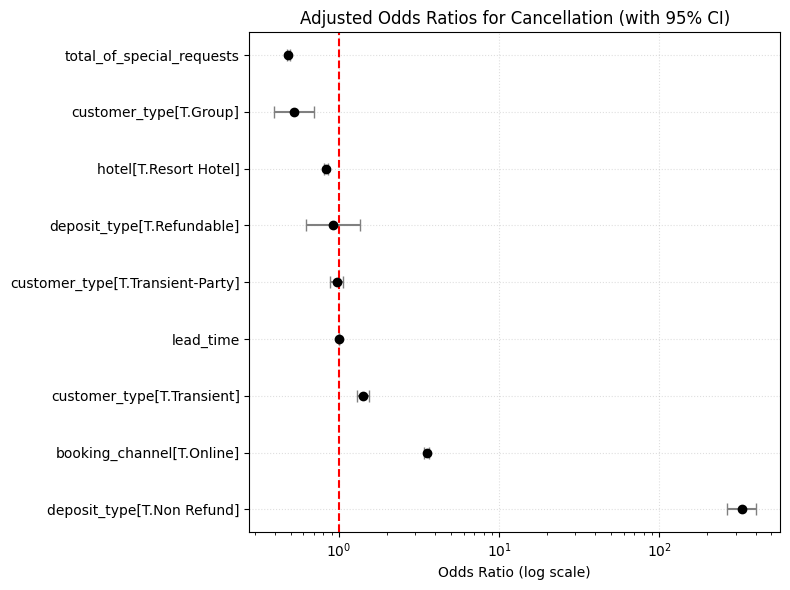

In [52]:
# ============================================================
# Step 7A: Visual Summary — Plot Odds Ratios from Final Model
# ============================================================

import matplotlib.pyplot as plt

# Reset index for clean plotting
plot_data = odds_table.reset_index()
plot_data = plot_data[plot_data['index'] != 'Intercept']  # Skip intercept

# Sort descending by Odds Ratio
plot_data.sort_values(by='Odds Ratio', ascending=False, inplace=True)

# Set figure size
plt.figure(figsize=(8, 6))

# Plot odds ratios with CI error bars
plt.errorbar(
    x=plot_data['Odds Ratio'],
    y=plot_data['index'],
    xerr=[
        plot_data['Odds Ratio'] - plot_data['CI Lower (2.5%)'],
        plot_data['CI Upper (97.5%)'] - plot_data['Odds Ratio']
    ],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4
)

# Add vertical line at OR = 1
plt.axvline(1, color='red', linestyle='--')

# Customize labels
plt.xlabel('Odds Ratio (log scale)')
plt.title('Adjusted Odds Ratios for Cancellation (with 95% CI)')
plt.xscale('log')
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.4)
plt.show()

# ------------------------------------------------------------
# Interpretation:
# - Points right of 1 increase cancellation odds
# - Points left of 1 reduce them
# - booking_channel[T.Online], deposit_type[T.Non Refund],
#   and special_requests have the strongest effects.
# ------------------------------------------------------------




#Key Observations:
#deposit_type[T.Non Refund] has the largest effect by far (OR ≈ 326):
# Cancelling is extremely unlikely under non-refundable terms.

#booking_channel[T.Online]: OR ≈ 3.55
# After adjustment, online bookings are over 3.5x more likely to be canceled than offline bookings.

#total_of_special_requests: OR < 1
# The more special requests, the less likely a cancellation — possibly due to higher planning effort or engagement.

#lead_time: OR slightly > 1
#Each additional day slightly increases cancellation odds.

#customer_type[T.Transient] increases odds, while customer_type[T.Group] strongly decreases them


In [53]:
# ========================================================
# Step 8A: Power Analysis for Two-Proportion Z-Test
# ========================================================

from statsmodels.stats.power import zt_ind_solve_power

# Observed proportions
p1 = 0.3672  # Online
p2 = 0.3733  # Offline

# Pooled standard deviation estimate
effect_size = abs(p1 - p2) / np.sqrt((p1 * (1 - p1) + p2 * (1 - p2)) / 2)

# Sample sizes
n1 = 56476
n2 = 62910
n_total = 1 / (1/n1 + 1/n2)  # Harmonic mean for unequal sizes

# Power calculation (two-sided test, alpha=0.05)
power = zt_ind_solve_power(effect_size=effect_size, nobs1=n_total, alpha=0.05, alternative='two-sided')

print(f"Post Hoc Power: {power:.4f}")

#“Given the observed difference in cancellation rates between Online and Offline groups, do we have enough power to detect that difference?”

#With over 119,000 observations, the power to detect such a small difference (~0.6%) is only 33.8%, which is well below the conventional 80% threshold.
#This means  study is underpowered to reliably detect such a small difference using a two-proportion test alone.


Post Hoc Power: 0.3379


In [54]:
# ========================================================
# Step 8B: What minimum effect size can we detect?
# ========================================================

# Solve for minimum detectable effect size given 80% power
min_effect = zt_ind_solve_power(
    effect_size=None,
    nobs1=n_total,
    alpha=0.05,
    power=0.80,
    alternative='two-sided'
)

# Convert back to raw difference (approximate)
avg_p = (p1 + p2) / 2
min_diff = min_effect * np.sqrt(2 * avg_p * (1 - avg_p))

print(f"Minimum detectable difference at 80% power: {min_diff:.4f}")

#“What is the minimum difference in cancellation rates I can detect at 80% power?”

# Current sample size is sufficient to detect differences in cancellation rates of 1.57% or larger.
#Since  actual observed difference is only 0.61%, it falls below the detection threshold — explaining why the two-proportion Z-test was not statistically significant, even with a large sample.

#However,  logistic regression model (adjusted for confounders) revealed a much stronger treatment effect — validating your experimental insight.


Minimum detectable difference at 80% power: 0.0157
